In [34]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [35]:
df = pd.read_csv('placement.csv')

In [36]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


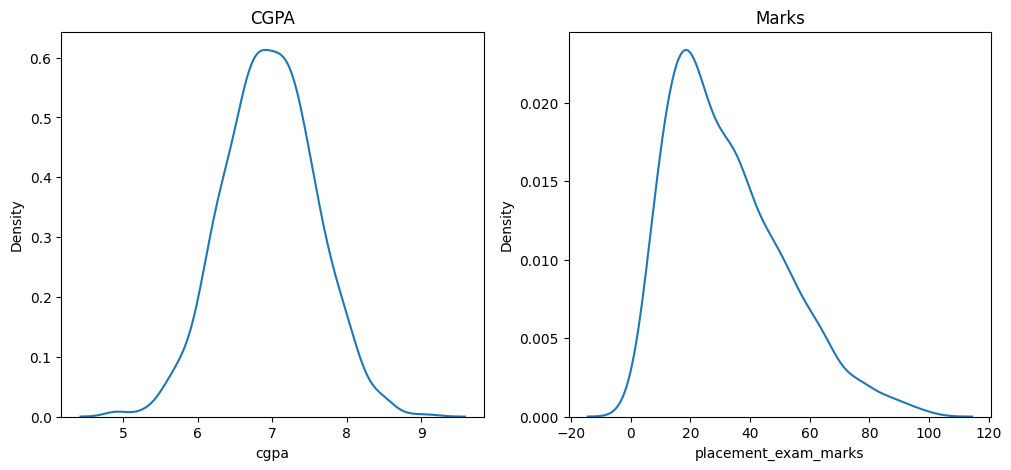

In [37]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.kdeplot(df['cgpa'])
plt.title('CGPA')

plt.subplot(1,2,2)
sns.kdeplot(df['placement_exam_marks'])
plt.title('Marks')
plt.show()

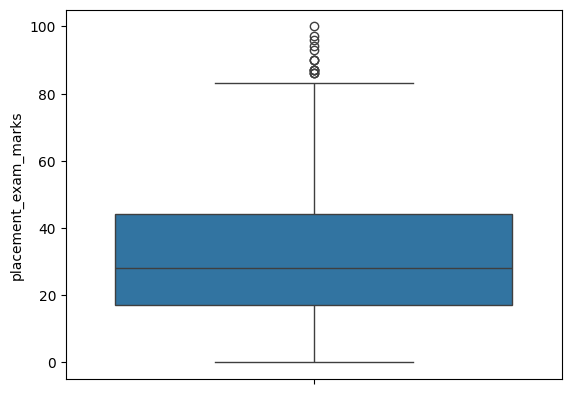

In [38]:
# we can see that the placement marks collumn is a bit skewed 
# ploting box plot to see the outliers 
sns.boxplot(df['placement_exam_marks'])
plt.show()

In [39]:
# we can see that there are some outliers now we will fetch them 
df.describe()['placement_exam_marks']

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

In [40]:
Q1 = 17.000000
Q3 = 44.000000
IQR = Q3-Q1
# we can use quantile also 

In [41]:
ll = Q1 - 1.5*IQR
ul = Q3 + 1.5*IQR

In [42]:
# we only use upper limit because there is no lower values 
df[df['placement_exam_marks']>ul].shape

(15, 3)

In [43]:
# here are 15 outliers 

# Trimming 

In [44]:
new_df_trimmed = df[df['placement_exam_marks']<=ul]

In [45]:
new_df_trimmed.shape

(985, 3)

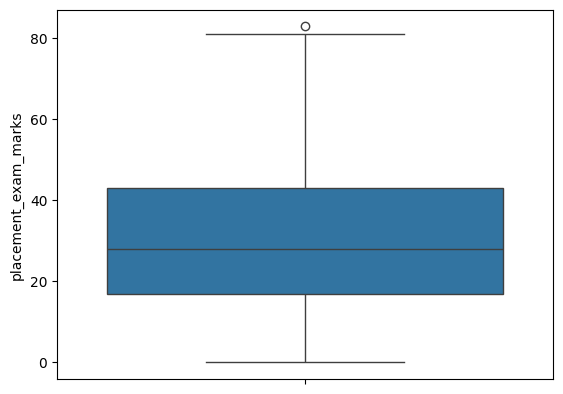

In [50]:
sns.boxplot(new_df_trimmed['placement_exam_marks'])
plt.show()
# we can see we removed almost all outliers

# Capping

In [47]:
df['placement_exam_marks'] = np.where(df['placement_exam_marks']>ub,ub,df['placement_exam_marks'])

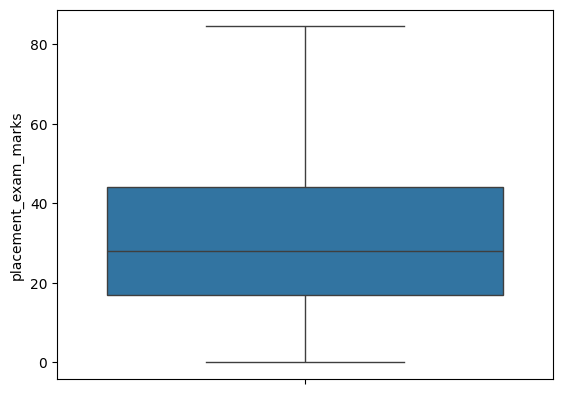

In [49]:
sns.boxplot(df['placement_exam_marks'])
plt.show()

In [ ]:
# now we can see there is no outlier 